In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import model_20250920
import simulate
from sklearn.metrics import r2_score
import importlib
from transformers import ViTConfig, ViTModel


In [10]:
device = "cpu"
random_seed = 2025
r2 = 0.5
n = 1000
dim = 112
coord, true_beta, img_data, y = simulate.simulate_data(n, r2, dim, random_seed)

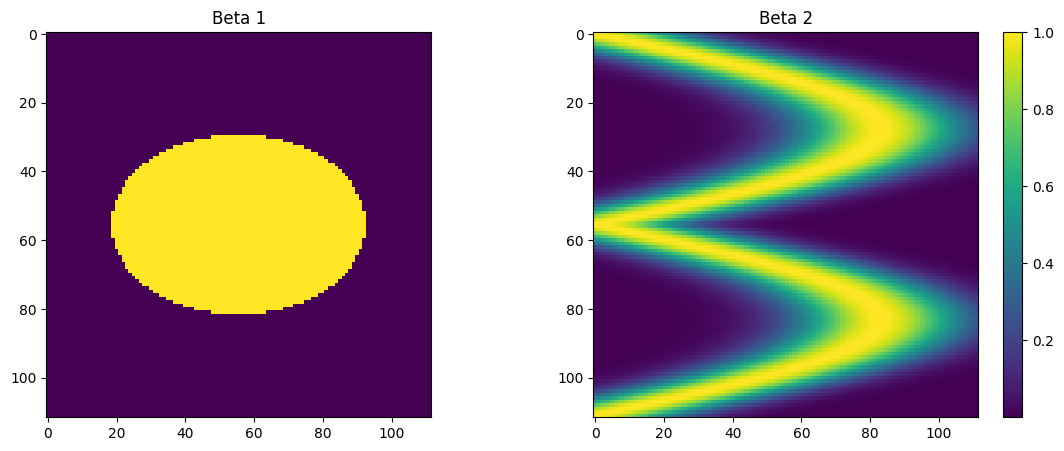

In [11]:
fig, axs = plt.subplots(1, 2, figsize = (14,5))
axs[0].imshow(true_beta[0].reshape(dim, dim))
axs[0].set_title("Beta 1")

cax = axs[1].imshow(true_beta[1].reshape(dim, dim))
axs[1].set_title("Beta 2")

fig.colorbar(cax, ax = axs[1])
plt.show()



In [12]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torchvision import transforms


img0 = img_data[0].reshape(n, dim, dim)
img1 = img_data[1].reshape(n, dim, dim)

# stacked_img = np.stack([img0, img1], axis=1)
# stacked_img = stacked_img[:, np.newaxis, :, :]
# stacked_img_tensor = torch.tensor(stacked_img, dtype = torch.float32).to(device)
# stacked_img = np.stack([img0, img1, np.zeros_like(img0)], axis=1)  # Add zero channel for blue
stacked_img = np.hstack([img0, img1]).reshape(-1, 1, 2*dim, dim)


stacked_img_tensor = torch.tensor(stacked_img, dtype=torch.float32).to(device)

# Add a resize transform to your data
# resize_transform = transforms.Resize((448, 448))

# Apply it to your tensors
# stacked_img_tensor = resize_transform(stacked_img_tensor)

y = y.reshape(-1, 1)
y_tensor = torch.tensor(y, dtype = torch.float32).to(device)

torch.manual_seed(random_seed)
np.random.seed(random_seed)

X_train, X_test, y_train, y_test = train_test_split(stacked_img_tensor, y_tensor, test_size = 0.2, random_state = random_seed)
train_dataset = TensorDataset(X_train, y_train)
test_dataset =  TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

In [13]:
import model_20250920
importlib.reload(model_20250920)      # Force-reload the module
from model_20250920 import CNN2d, DNNModel , RegressionViT, RegressionViT2, RegressionViT3, RegressionViT4        # Import the updated class

In [14]:
def train_vit_model(model_class=model_20250920.RegressionViT3, 
                    lr=1e-5,
                    dropout_prob=0.1, 
                    weight_decay=0.0, 
                    num_epochs=100, 
                    num_channels=1,
                    train_loader=None, 
                    test_loader=None, 
                    device='cuda' if torch.cuda.is_available() else 'cpu',
                    verbose=True,
                    plot_results=True):
    """
    Train a ViT model with customizable parameters and track performance metrics.
    
    Args:
        model_class: ViT model class
        lr: Learning rate (default: 1e-5)
        dropout_prob: dropout probability (default: 0.1)
        weight_decay: L2 regularization (default: 0.0)
        num_epochs: Number of training epochs (default: 20)
        num_channels：
        train_loader: Training data loader
        test_loader: Test/validation data loader
        device: Device to run training on
        verbose: Whether to print training progress
        plot_results: Whether to plot learning curves
    
    Returns:
        Dictionary containing training history and best metrics
    """
    # Initialize model, criterion and optimizer
    vit = model_class(num_classes=1, dropout_prob=dropout_prob, image_size=(224,112), num_channels=num_channels
                     ).to(device)
    criterion = torch.nn.MSELoss()
    optimizer = optim.Adam(vit.parameters(), lr=lr, weight_decay=weight_decay)

    # Initialize lists to track metrics
    train_losses = []
    test_losses = []
    all_train_r2 = []
    all_test_r2 = []
    
    best_epoch = 0
    best_test_loss = float('inf')
    best_test_r2 = -float('inf')

    for epoch in range(num_epochs):
        # --- Training Phase ---
        vit.train()
        running_loss = 0.0
        y_pred, y_true = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_hat_batch = vit(X_batch)
            loss = criterion(y_hat_batch, y_batch)
            loss.backward()
            optimizer.step()
            
            with torch.no_grad():
                running_loss += loss.item()
                y_pred.extend(y_hat_batch.detach().cpu().numpy().flatten())
                y_true.extend(y_batch.cpu().numpy().flatten())
        
        # Calculate training metrics
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        train_r2 = r2_score(y_true, y_pred)
        all_train_r2.append(train_r2)
        
        # --- Validation/Test Phase ---
        vit.eval()
        with torch.no_grad():
            test_pred, test_true = [], []
            test_running_loss = 0.0
            
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_hat_batch = vit(X_batch)
                loss = criterion(y_hat_batch, y_batch)
                test_running_loss += loss.item()
                test_pred.extend(y_hat_batch.detach().cpu().numpy().flatten())
                test_true.extend(y_batch.cpu().numpy().flatten())
            
            epoch_test_loss = test_running_loss / len(test_loader)
            test_losses.append(epoch_test_loss)
            test_r2 = r2_score(test_true, test_pred)
            all_test_r2.append(test_r2)
            
            # Update best epoch
            if epoch_test_loss < best_test_loss:
                best_test_loss = epoch_test_loss
                best_test_r2 = test_r2
                best_epoch = epoch + 1
        
        # Print metrics if verbose
        # if verbose and (epoch + 1) % 1 == 0:
        #     print(f"Epoch {epoch + 1}/{num_epochs}")
        #     print(f"  Train Loss: {epoch_train_loss:.4f} ± {np.std(train_losses):.4f}")
        #     print(f"  Train R²: {train_r2:.4f} ± {np.std(all_train_r2):.4f}")
        #     print(f"  Test Loss: {epoch_test_loss:.4f} ± {np.std(test_losses):.4f}")
        #     print(f"  Test R²: {test_r2:.4f} ± {np.std(all_test_r2):.4f}\n")

    # Final summary
    if verbose:
        print(f"\n=== {model_class.__name__} Training Summary ===")
        print(f"Best Epoch: {best_epoch}")
        print(f"Best Test Loss: {best_test_loss:.4f}")
        print(f"Corresponding Test R²: {best_test_r2:.4f}")
        print(f"Final Train Loss: {train_losses[-1]:.4f} ± {np.std(train_losses):.4f}")
        print(f"Final Train R²: {all_train_r2[-1]:.4f} ± {np.std(all_train_r2):.4f}")
        print(f"Final Test Loss: {test_losses[-1]:.4f} ± {np.std(test_losses):.4f}")
        print(f"Final Test R²: {all_test_r2[-1]:.4f} ± {np.std(all_test_r2):.4f}")

    # Plot results if requested
    if plot_results:
        plt.figure(figsize=(12, 5))

        # Plot Losses
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.title(f'{model_class.__name__} Training & Test Loss')
        plt.legend()

        # Plot R² Scores
        plt.subplot(1, 2, 2)
        plt.plot(all_train_r2, label='Train R²')
        plt.plot(all_test_r2, label='Test R²')
        plt.xlabel('Epoch')
        plt.ylabel('R² Score')
        plt.title(f'{model_class.__name__} R² Scores')
        plt.legend()

        plt.tight_layout()
        plt.show()

    return {
        'model': RegressionViT,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_r2_scores': all_train_r2,
        'test_r2_scores': all_test_r2,
        'best_epoch': best_epoch,
        'best_test_loss': best_test_loss,
        'best_test_r2': best_test_r2,
        'final_train_loss': train_losses[-1],
        'final_test_loss': test_losses[-1],
        'final_train_r2': all_train_r2[-1],
        'final_test_r2': all_test_r2[-1]
    }

# Example usage:
# results = train_vit_model(model_class=model.RegrssionViT,
#                         lr=0.0001,
#                         dropout_prob=0.1,
#                         weight_decay=0.01,
#                         num_epochs=100,
#                         train_loader=train_loader,
#                         test_loader=test_loader)

In [15]:
import model_20250920
importlib.reload(model_20250920)      # Force-reload the module
from model_20250920 import CNN2d, DNNModel, RegressionViT, RegressionViT2, RegressionViT3, RegressionViT4        # Import the updated class


=== RegressionViT3 Training Summary ===
Best Epoch: 97
Best Test Loss: 130.9922
Corresponding Test R²: 0.1633
Final Train Loss: 76.4451 ± 19.9895
Final Train R²: 0.5074 ± 0.1288
Final Test Loss: 137.4802 ± 5.2453
Final Test R²: 0.1129 ± 0.0362


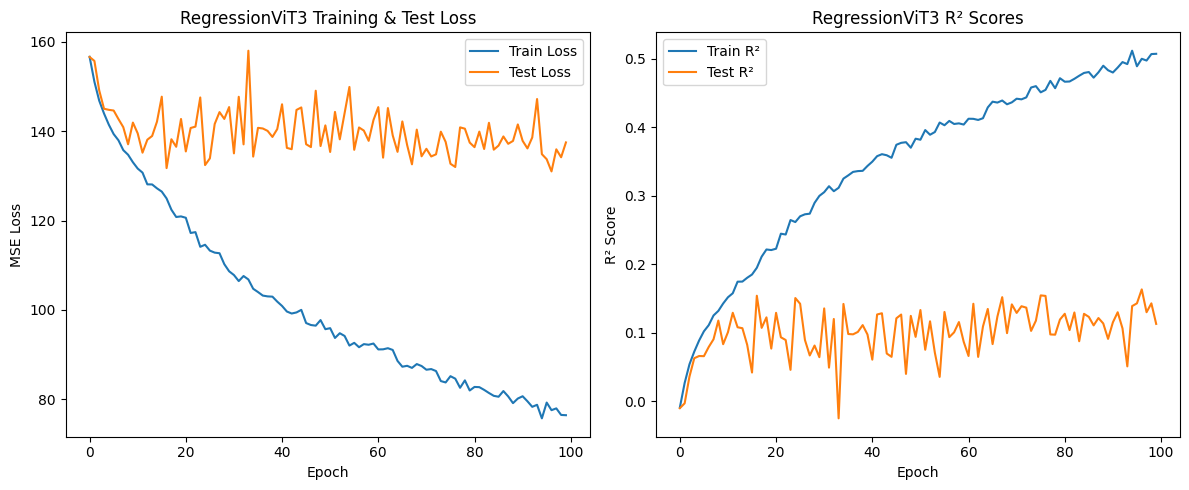

In [16]:
# session 1
results = train_vit_model(model_class=model_20250920.RegressionViT3,
                        lr=1e-5,
                        dropout_prob=0.1,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT3 Training Summary ===
Best Epoch: 93
Best Test Loss: 127.3939
Corresponding Test R²: 0.1822
Final Train Loss: 80.6017 ± 19.5245
Final Train R²: 0.4806 ± 0.1258
Final Test Loss: 132.9179 ± 5.4354
Final Test R²: 0.1403 ± 0.0369


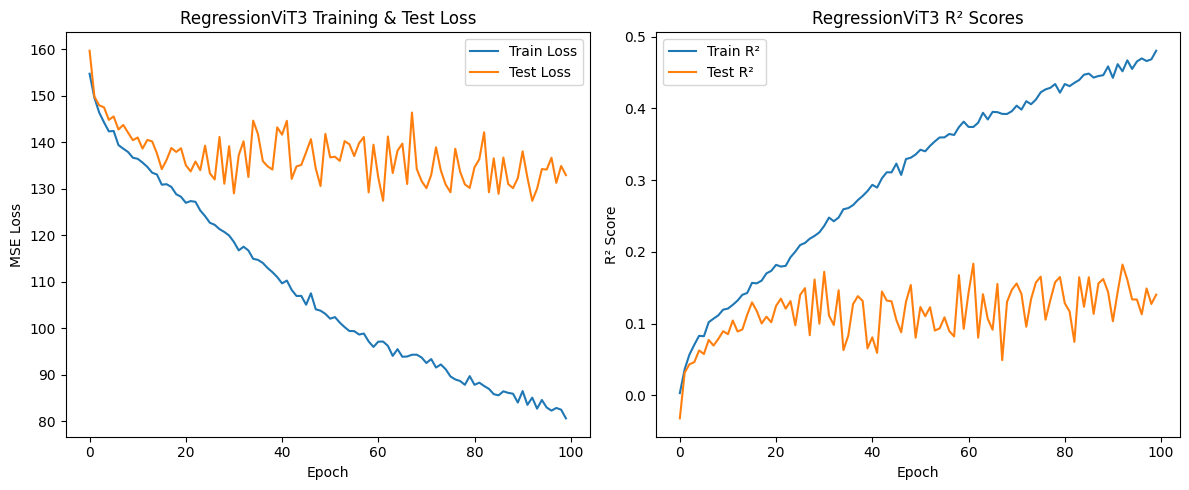

In [17]:
# session 2 
results = train_vit_model(model_class=model_20250920.RegressionViT3,
                        lr=1e-5,
                        dropout_prob=0.2,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT3 Training Summary ===
Best Epoch: 97
Best Test Loss: 140.3610
Corresponding Test R²: 0.1014
Final Train Loss: 102.6998 ± 15.8966
Final Train R²: 0.3382 ± 0.1024
Final Test Loss: 140.9921 ± 4.0053
Final Test R²: 0.0875 ± 0.0271


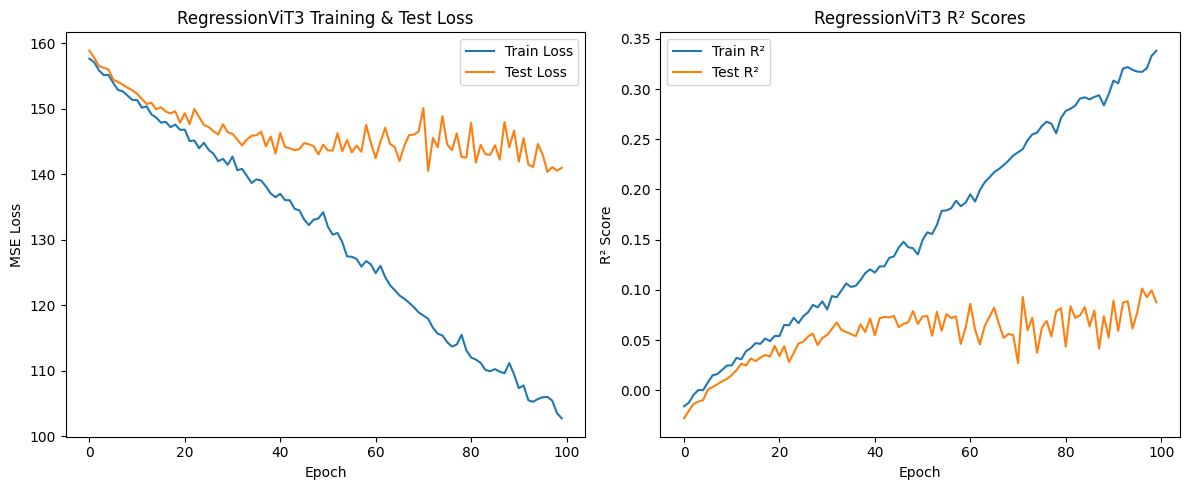

In [18]:
# session 3 
results = train_vit_model(model_class=model_20250920.RegressionViT3,
                        lr=1e-5,
                        dropout_prob=0.5,
                        weight_decay=0.01,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT3 Training Summary ===
Best Epoch: 85
Best Test Loss: 134.3074
Corresponding Test R²: 0.1308
Final Train Loss: 121.5551 ± 9.2379
Final Train R²: 0.2167 ± 0.0595
Final Test Loss: 134.6853 ± 6.1026
Final Test R²: 0.1280 ± 0.0395


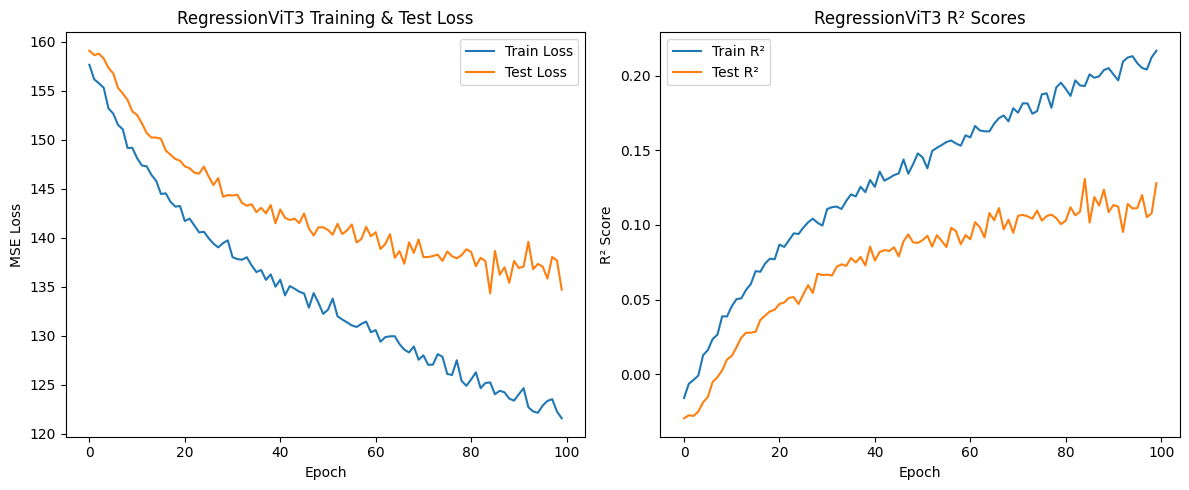

In [19]:
# session 4
results = train_vit_model(model_class=model_20250920.RegressionViT3,
                        lr=1e-6,
                        dropout_prob=0.1,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT3 Training Summary ===
Best Epoch: 99
Best Test Loss: 139.8976
Corresponding Test R²: 0.0969
Final Train Loss: 136.8397 ± 5.4781
Final Train R²: 0.1182 ± 0.0353
Final Test Loss: 141.6337 ± 5.0955
Final Test R²: 0.0841 ± 0.0338


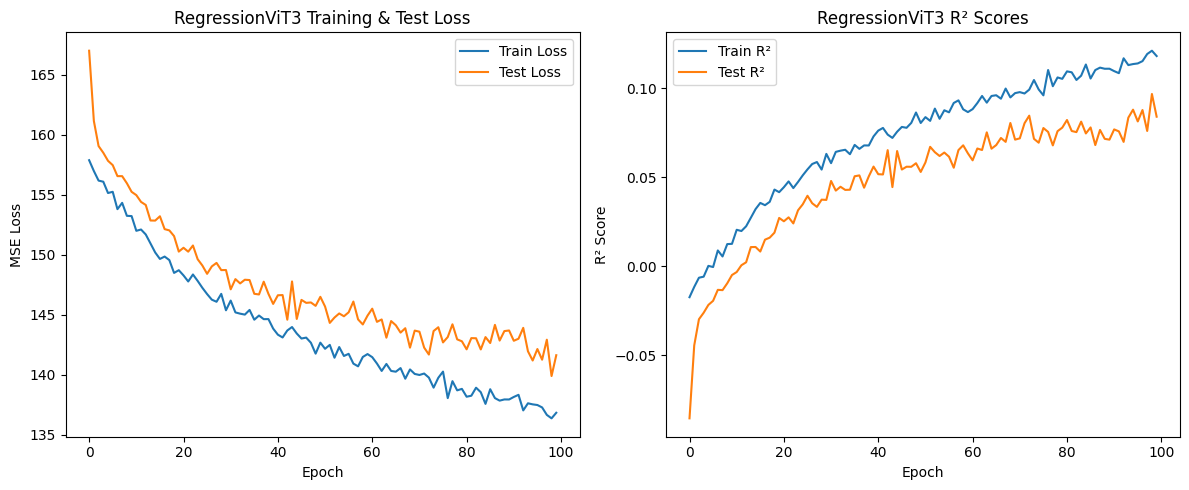

In [20]:
# session 5
results = train_vit_model(model_class=model_20250920.RegressionViT3,
                        lr=1e-6,
                        dropout_prob=0.2,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT3 Training Summary ===
Best Epoch: 97
Best Test Loss: 150.0985
Corresponding Test R²: 0.0307
Final Train Loss: 147.3997 ± 2.3518
Final Train R²: 0.0502 ± 0.0152
Final Test Loss: 150.5676 ± 2.0322
Final Test R²: 0.0274 ± 0.0137


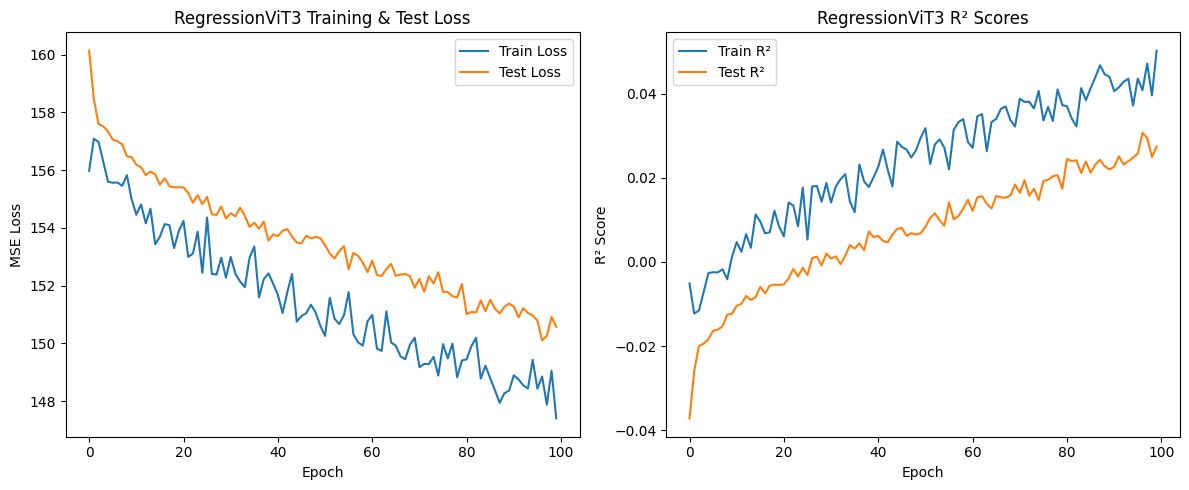

In [21]:
# session 6
results = train_vit_model(model_class=model_20250920.RegressionViT3,
                        lr=1e-6,
                        dropout_prob=0.5,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT4 Training Summary ===
Best Epoch: 60
Best Test Loss: 97.9982
Corresponding Test R²: 0.3719
Final Train Loss: 81.4767 ± 14.4509
Final Train R²: 0.4750 ± 0.0931
Final Test Loss: 127.8793 ± 8.1124
Final Test R²: 0.1738 ± 0.0534


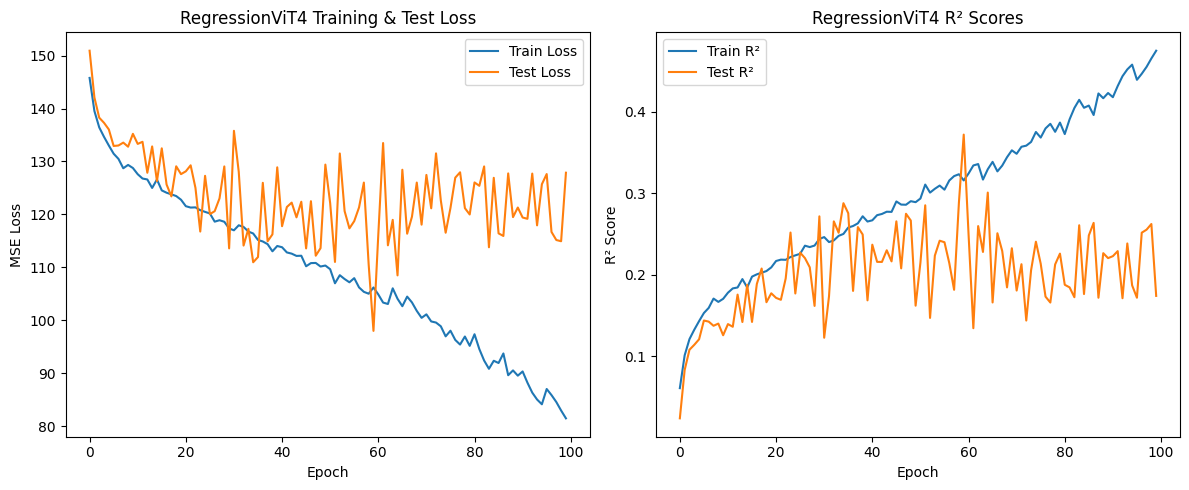

In [22]:
# session 7
results = train_vit_model(model_class=model_20250920.RegressionViT4,
                        lr=1e-5,
                        dropout_prob=0.1,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT4 Training Summary ===
Best Epoch: 75
Best Test Loss: 108.0264
Corresponding Test R²: 0.3032
Final Train Loss: 86.5263 ± 15.0928
Final Train R²: 0.4424 ± 0.0973
Final Test Loss: 124.8035 ± 9.0849
Final Test R²: 0.1982 ± 0.0598


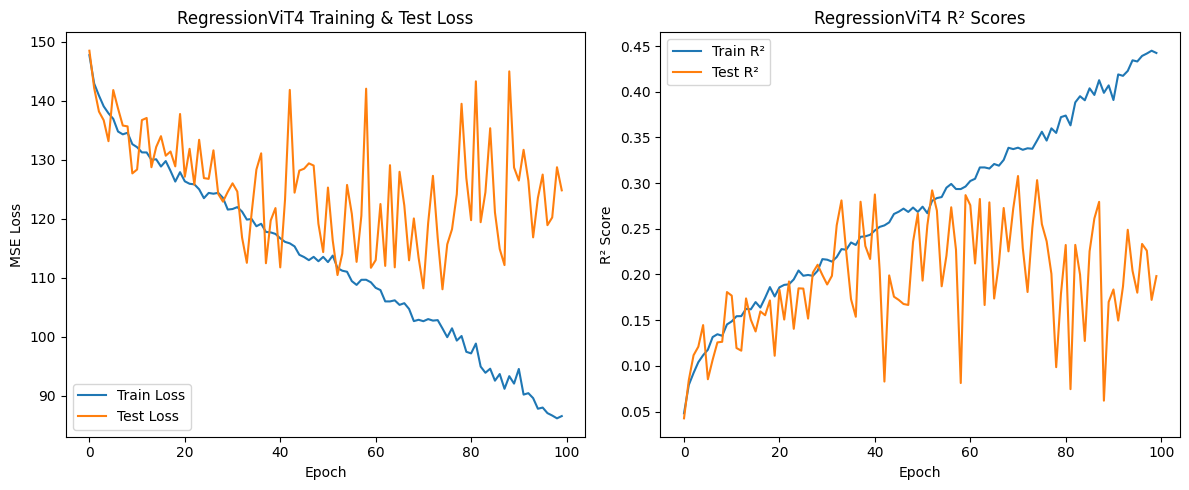

In [23]:
# session8 
results = train_vit_model(model_class=model_20250920.RegressionViT4,
                        lr=1e-5,
                        dropout_prob=0.2,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT4 Training Summary ===
Best Epoch: 90
Best Test Loss: 121.0626
Corresponding Test R²: 0.2257
Final Train Loss: 117.8399 ± 10.5320
Final Train R²: 0.2406 ± 0.0679
Final Test Loss: 126.8713 ± 9.0074
Final Test R²: 0.1866 ± 0.0598


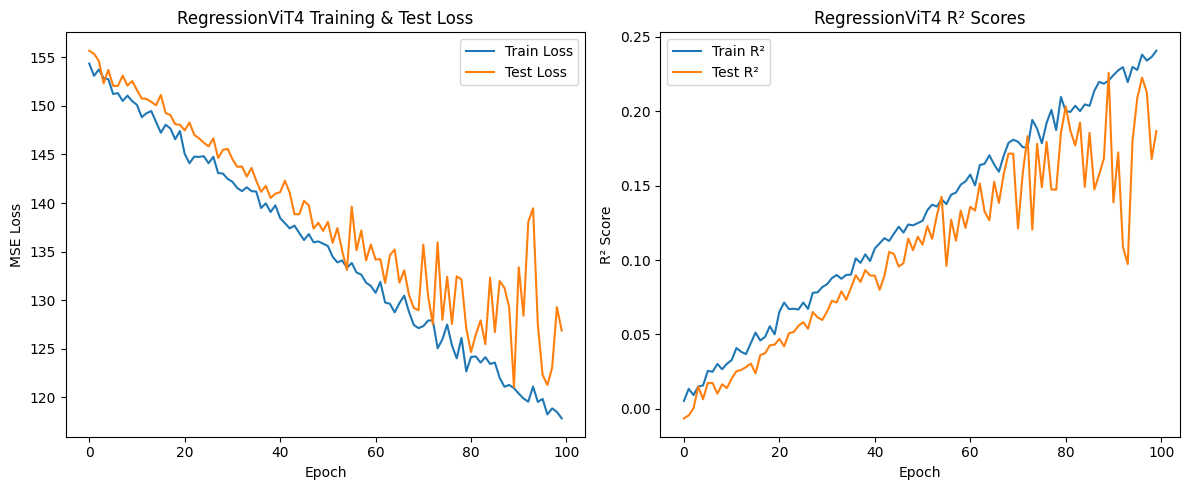

In [24]:
# session 9
results = train_vit_model(model_class=model_20250920.RegressionViT4,
                        lr=1e-5,
                        dropout_prob=0.5,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT4 Training Summary ===
Best Epoch: 78
Best Test Loss: 129.7798
Corresponding Test R²: 0.1626
Final Train Loss: 127.9738 ± 4.8435
Final Train R²: 0.1753 ± 0.0312
Final Test Loss: 132.0110 ± 4.1318
Final Test R²: 0.1468 ± 0.0269


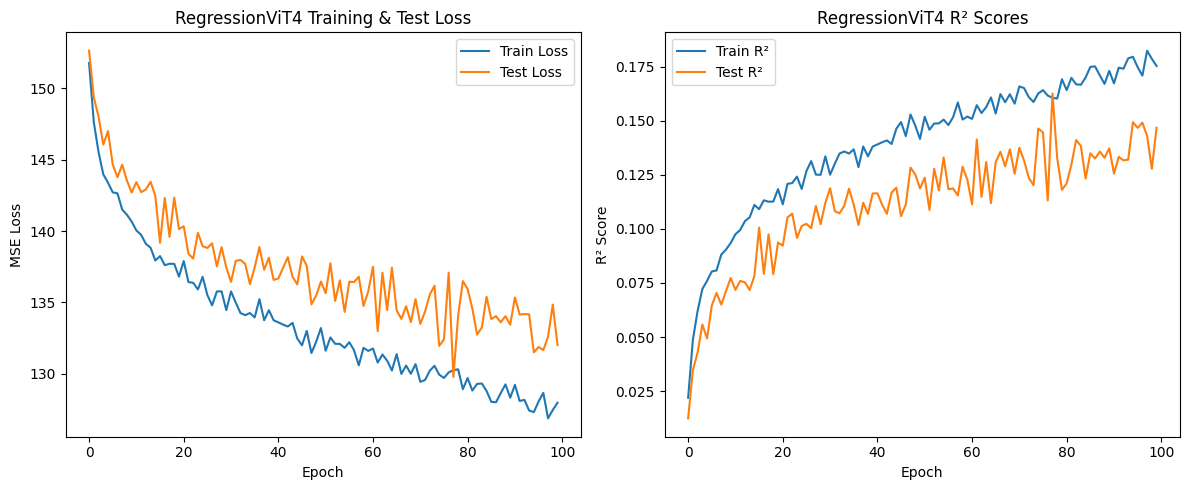

In [25]:
# session 10
results = train_vit_model(model_class=model_20250920.RegressionViT4,
                        lr=1e-6,
                        dropout_prob=0.1,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT4 Training Summary ===
Best Epoch: 95
Best Test Loss: 133.5208
Corresponding Test R²: 0.1385
Final Train Loss: 130.4315 ± 5.0415
Final Train R²: 0.1595 ± 0.0325
Final Test Loss: 135.5614 ± 4.4530
Final Test R²: 0.1242 ± 0.0291


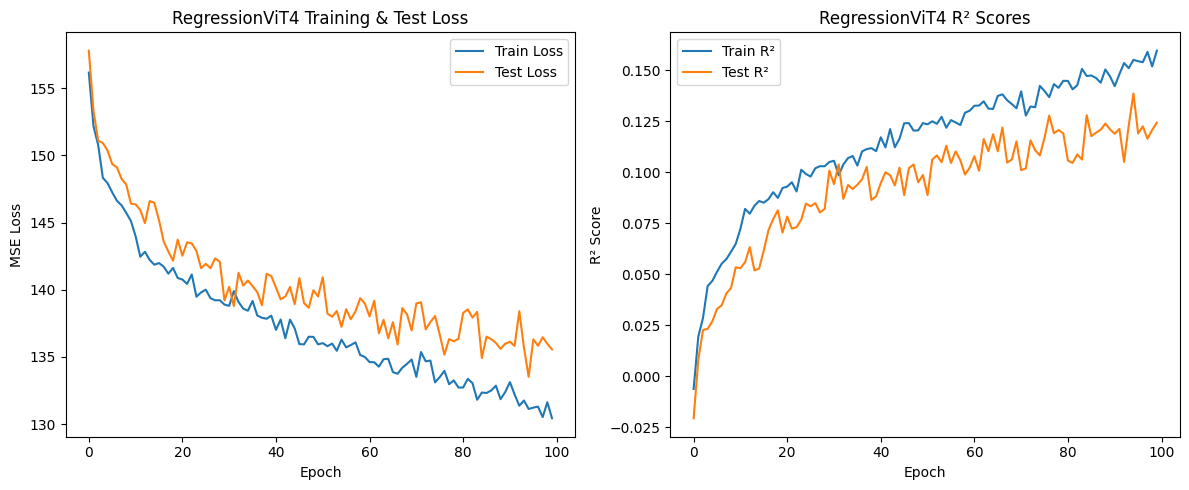

In [26]:
# session 11
results = train_vit_model(model_class=model_20250920.RegressionViT4,
                        lr=1e-6,
                        dropout_prob=0.2,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)


=== RegressionViT4 Training Summary ===
Best Epoch: 99
Best Test Loss: 146.6536
Corresponding Test R²: 0.0518
Final Train Loss: 146.1518 ± 2.4207
Final Train R²: 0.0582 ± 0.0156
Final Test Loss: 148.0939 ± 2.5525
Final Test R²: 0.0425 ± 0.0165


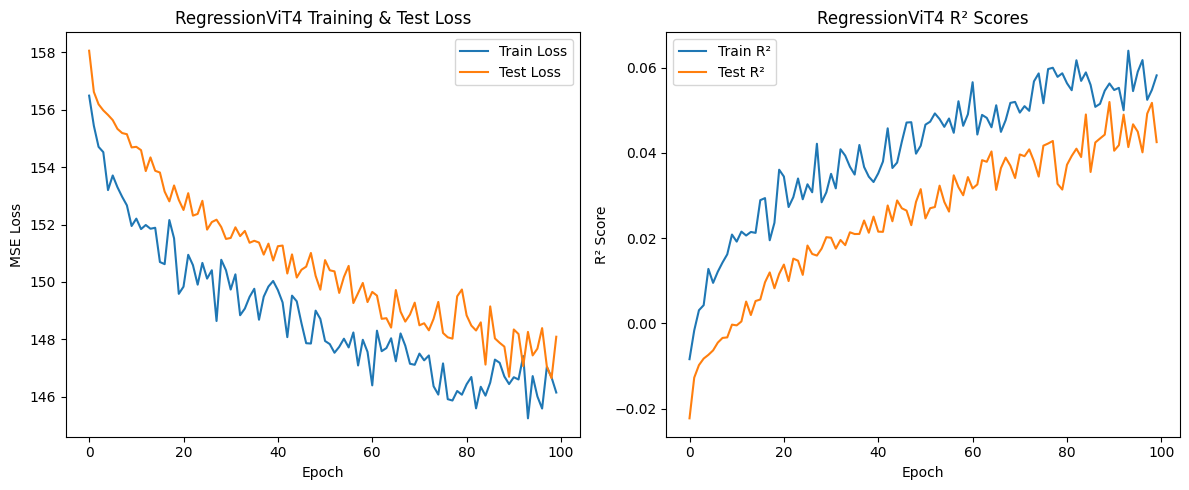

In [27]:
# session 12
results = train_vit_model(model_class=model_20250920.RegressionViT4,
                        lr=1e-6,
                        dropout_prob=0.5,
                        weight_decay=0.0,
                        num_epochs=100,
                        num_channels=1,
                        train_loader=train_loader,
                        test_loader=test_loader)